In [49]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [50]:
data = pd.read_csv('C:\\Users\\USER\\Desktop\\학회\\데이터\\data_collection_v1.csv')

# Date 컬럼을 datetime으로 변환 (문제 원인 해결)
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# 결측 날짜가 있는 행 제거
data = data.dropna(subset=['Date'])

print(data.head())
print("\n")
data['KOSPI 200'].info()

        Date  Shanghai Comp     KODEX 200       TOPIX  Brent Crude Oil  \
0 2009-04-17    2503.935059  12910.512695  679.428345        51.959999   
1 2009-04-20    2557.456055  12992.272461  680.204895        51.959999   
2 2009-04-21    2535.827881  12992.272461  663.898560        51.959999   
3 2009-04-22    2461.345947  13166.933594  664.675110        51.959999   
4 2009-04-23    2463.954102  13300.729492  669.333984        51.959999   

   USD/CNY   Gold Spot  KRW/JPY      KRW/USD      KOSDAQ   KOSPI 200  \
0   6.8226  867.400024   13.371  1325.800049  483.799988  171.330002   
1   6.8230  887.000000   13.536  1327.500000  491.940002  172.300003   
2   6.8169  882.099976   13.727  1354.300049  497.190002  171.960007   
3   6.8195  891.799988   13.726  1346.599976  509.899994  174.399994   
4   6.8193  905.900024   13.618  1333.599976  514.090027  176.139999   

      KRW/CNY  
0  194.324755  
1  194.562510  
2  198.668030  
3  197.463154  
4  195.562586  


<class 'pandas.core.seri

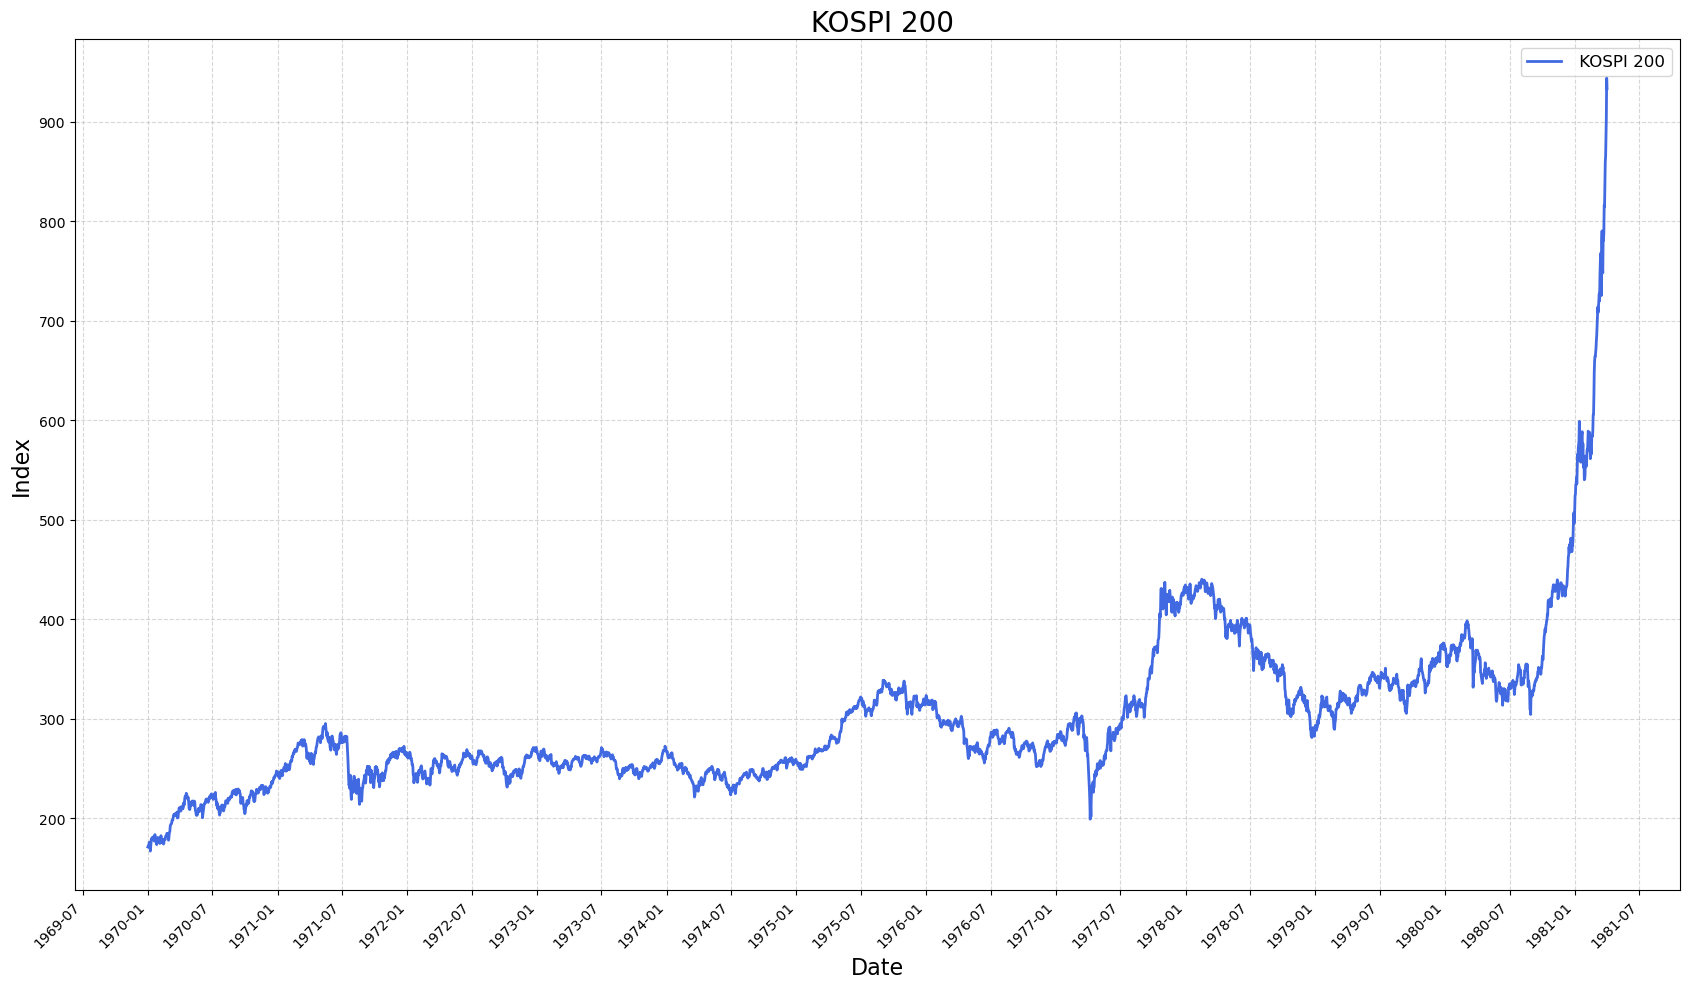

In [51]:
plt.figure(figsize=(17, 10))
plt.plot(data.index, data['KOSPI 200'], label=' KOSPI 200', color='royalblue', linewidth=2)
plt.title(' KOSPI 200', fontsize=20)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Index', fontsize=16)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12)
plt.show()

### Moving Average, Bollinger Band, Realtive Strength Index

In [63]:
def MA(series, window):
    return series.rolling(window=window, min_periods=1).mean()

def BB(series, window, k): # @시훈 걍 window내의 신뢰구간 같은거임
    ma = MA(series, window)
    std = series.rolling(window=window, min_periods=2).std()  # std 최소 2개 값 필요
    upper_band = ma + (std * k)
    lower_band = ma - (std * k)
    
    return upper_band, lower_band

def RSI(series, window):   #@시훈 상대강도지수, 0~100사이의 값으로 나타남, 상승과 하강중 무엇이 강했는지
    delta = series.diff()
    gain = delta.where(delta > 0, 0)    
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window, min_periods=1).mean()  # 최소 2개
    avg_loss = loss.rolling(window=window, min_periods=1).mean()  # 최소 2개
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

In [68]:
# BB와 RSI 계산
window_bb = 20  # Bollinger Band 기간
k_bb = 2        # 표준편차 배수
window_rsi = 14 # RSI 기간

# Bollinger Bands 계산
data['MA'] = MA(data['KOSPI 200'], window_bb)
data['BB_upper'], data['BB_lower'] = BB(data['KOSPI 200'], window_bb, k_bb)

# RSI 계산
data['RSI'] = RSI(data['KOSPI 200'], window_rsi)

# 결과 확인
print("\t\t\tHEAD\n", data[['Date','KOSPI 200','BB_upper','BB_lower','RSI']].head(), "\n")
print("\t\t\tTAIL\n", data[['Date','KOSPI 200','BB_upper','BB_lower','RSI']].tail())

##### window크기에 따라 초기값은 데이터의 크기만큼을 window로 잡음
##### 초기

			HEAD
         Date   KOSPI 200    BB_upper    BB_lower         RSI
0 2009-04-17  171.330002         NaN         NaN         NaN
1 2009-04-20  172.300003  173.186791  170.443214  100.000000
2 2009-04-21  171.960007  172.847683  170.878991   74.046033
3 2009-04-22  174.399994  175.158438  169.836564   90.933394
4 2009-04-23  176.139999  177.216574  169.235428   93.806977 

			TAIL
            Date   KOSPI 200    BB_upper    BB_lower        RSI
4104 2026-02-23  865.489990  864.910875  690.544124  68.223275
4105 2026-02-24  886.880005  881.754754  690.158247  70.239526
4106 2026-02-25  903.830017  899.901267  689.665737  83.443951
4107 2026-02-26  944.020020  924.448913  687.516096  82.534216
4108 2026-02-27  933.340027  943.050968  687.735042  78.295462


In [70]:
data.to_csv('C:\\Users\\USER\\Desktop\\학회\\데이터\\data_prepro_BB,RSI.csv', index=False)